# Predicting Irrigation Need

Link to Competittion: https://www.kaggle.com/competitions/playground-series-s6e4/overview

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.figsize'] = (12, 6)

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

import xgboost as xgb

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc, accuracy_score, confusion_matrix, mean_squared_error, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, RandomizedSearchCV, train_test_split
from sklearn.cluster import KMeans

from common import *

In [2]:
from platform import python_version
print('python: ', python_version())
print('pandas: ', pd.__version__)
print('numpy: ', np.__version__)
import matplotlib
print('matplotlib: ', matplotlib.__version__)
print('seaborn: ', sns.__version__)
import sklearn
print('sklearn: ', sklearn.__version__)
print('xgboost: ', xgb.__version__)

python:  3.13.11
pandas:  2.3.3
numpy:  2.3.5
matplotlib:  3.10.8
seaborn:  0.13.2
sklearn:  1.8.0
xgboost:  3.2.0


## Helpers

## Load data

In [3]:
train_df = pd.read_csv('archive/train.csv')
test_df = pd.read_csv('archive/test.csv')
orig_df = pd.read_csv('archive/irrigation_prediction.csv')

In [4]:
train_df

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South,Medium
629996,629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central,Medium
629997,629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South,High
629998,629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,5.00,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East,Low


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [6]:
train_df['Irrigation_Need'].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

### Look for NaN values

In [8]:
train_df.isnull().sum() 

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

### Look for duplicates

In [9]:
train_df.duplicated().sum()

np.int64(0)

## Call the pipeline

In [10]:
df = (train_df
          .pipe(copy_data)
          .pipe(clean_data)
          # .pipe(remove_outliers)
          .pipe(remove_duplicates)
          .pipe(make_new_features)
           )

## Features

In [11]:
target = get_target()

In [12]:
features = get_features(df)

In [13]:
features

['soil_type',
 'soil_ph',
 'soil_moisture',
 'organic_carbon',
 'electrical_conductivity',
 'temperature_c',
 'humidity',
 'rainfall_mm',
 'sunlight_hours',
 'wind_speed_kmh',
 'crop_type',
 'crop_growth_stage',
 'season',
 'irrigation_type',
 'water_source',
 'field_area_hectare',
 'mulching_used',
 'previous_irrigation_mm',
 'region']

In [14]:
categorical_features = [
    'crop_type',
    'crop_growth_stage',
    'season',
    'irrigation_type',
    'water_source',
    'field_area_hectare',
    'mulching_used',
    'soil_type'
]

In [15]:
numerical_features = [f for f in features if f not in categorical_features]

In [16]:
categorical_features

['crop_type',
 'crop_growth_stage',
 'season',
 'irrigation_type',
 'water_source',
 'field_area_hectare',
 'mulching_used',
 'soil_type']

In [17]:
numerical_features

['soil_ph',
 'soil_moisture',
 'organic_carbon',
 'electrical_conductivity',
 'temperature_c',
 'humidity',
 'rainfall_mm',
 'sunlight_hours',
 'wind_speed_kmh',
 'previous_irrigation_mm',
 'region']

In [18]:
df[features]

,soil_type,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,temperature_c,humidity,rainfall_mm,sunlight_hours,wind_speed_kmh,crop_type,crop_growth_stage,season,irrigation_type,water_source,field_area_hectare,mulching_used,previous_irrigation_mm,region
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,Clay,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,Rice,Sowing,Kharif,Sprinkler,River,4.35,No,118.36,South
629996,Clay,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,Sugarcane,Vegetative,Kharif,Drip,Groundwater,12.97,Yes,40.75,Central
629997,Clay,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,Potato,Vegetative,Zaid,Canal,Reservoir,13.58,Yes,2.62,South
629998,Clay,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,5.00,Sugarcane,Vegetative,Zaid,Sprinkler,Groundwater,0.79,Yes,90.00,East


In [19]:
df = pd.get_dummies(df[features], dtype='int')

In [20]:
df[target] = train_df['Irrigation_Need']

In [21]:
df[target].value_counts()

irrigation_need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [22]:
df[target] = df[target].map({'Low': 1, 'Medium': 2, 'High': 3})

### Look at column types

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 44 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   soil_ph                       630000 non-null  float64
 1   soil_moisture                 630000 non-null  float64
 2   organic_carbon                630000 non-null  float64
 3   electrical_conductivity       630000 non-null  float64
 4   temperature_c                 630000 non-null  float64
 5   humidity                      630000 non-null  float64
 6   rainfall_mm                   630000 non-null  float64
 7   sunlight_hours                630000 non-null  float64
 8   wind_speed_kmh                630000 non-null  float64
 9   field_area_hectare            630000 non-null  float64
 10  previous_irrigation_mm        630000 non-null  float64
 11  soil_type_Clay                630000 non-null  int64  
 12  soil_type_Loamy               630000 non-nul

## Describe

In [24]:
df.describe()

,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,temperature_c,humidity,rainfall_mm,sunlight_hours,wind_speed_kmh,field_area_hectare,previous_irrigation_mm,soil_type_Clay,soil_type_Loamy,soil_type_Sandy,soil_type_Silt,crop_type_Cotton,crop_type_Maize,crop_type_Potato,crop_type_Rice,crop_type_Sugarcane,crop_type_Wheat,crop_growth_stage_Flowering,crop_growth_stage_Harvest,crop_growth_stage_Sowing,crop_growth_stage_Vegetative,season_Kharif,season_Rabi,season_Zaid,irrigation_type_Canal,irrigation_type_Drip,irrigation_type_Rainfed,irrigation_type_Sprinkler,water_source_Groundwater,water_source_Rainwater,water_source_Reservoir,water_source_River,mulching_used_No,mulching_used_Yes,region_Central,region_East,region_North,region_South,region_West,irrigation_need
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.00000,630000.000000,630000.000000,630000.000000,630000.000000,630000.00000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177,0.251540,0.248341,0.26430,0.235819,0.166103,0.165514,0.162649,0.16936,0.172873,0.163500,0.250100,0.266173,0.234130,0.249597,0.343748,0.330211,0.326041,0.256986,0.239829,0.246995,0.256190,0.244690,0.242908,0.258721,0.253681,0.502306,0.497694,0.196368,0.200259,0.181154,0.213983,0.208237,1.446178
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939,0.433898,0.432051,0.44096,0.424510,0.372174,0.371644,0.369046,0.37507,0.378138,0.369822,0.433071,0.441956,0.423454,0.432780,0.474958,0.470289,0.468763,0.436972,0.426979,0.431264,0.436529,0.429904,0.428840,0.437932,0.435117,0.499995,0.499995,0.397251,0.400194,0.385146,0.410115,0.406047,0.560178
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000,1.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,

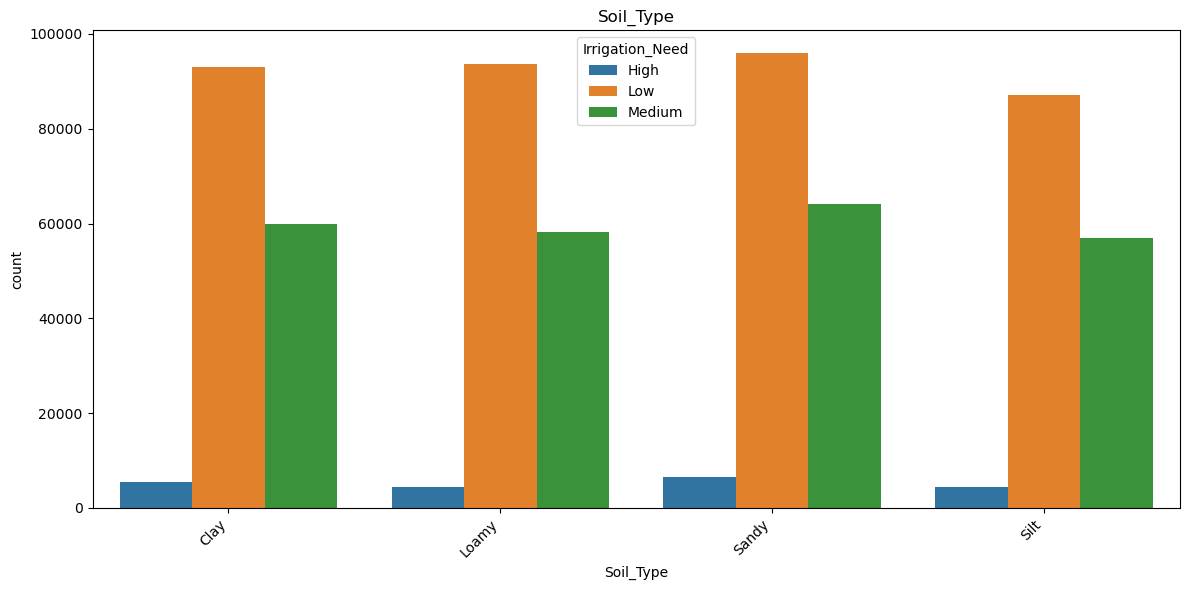

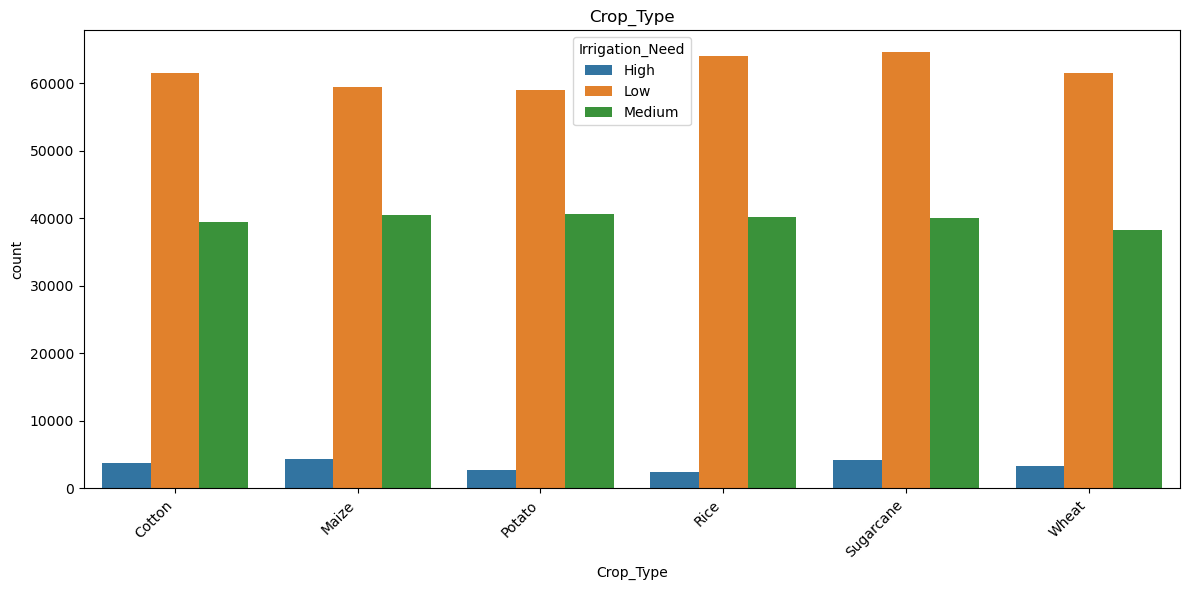

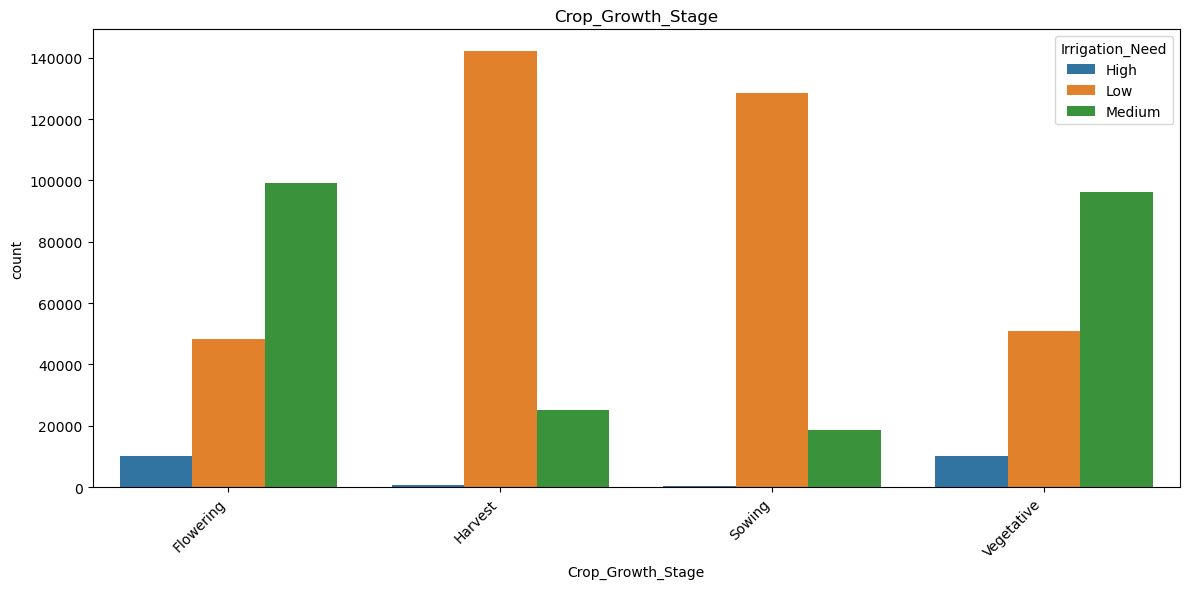

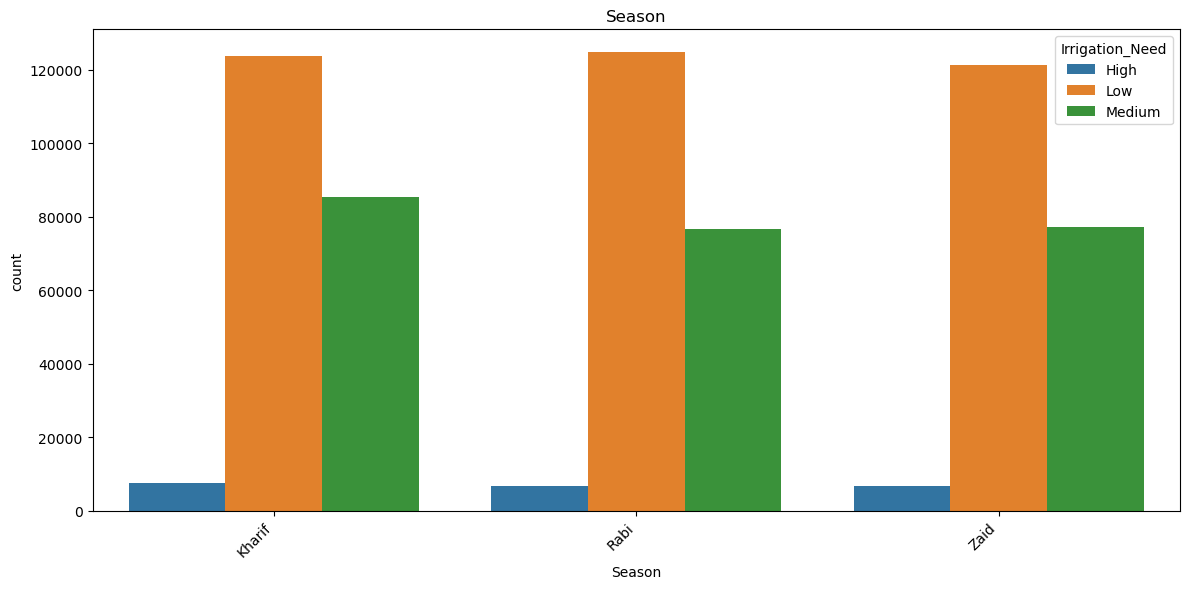

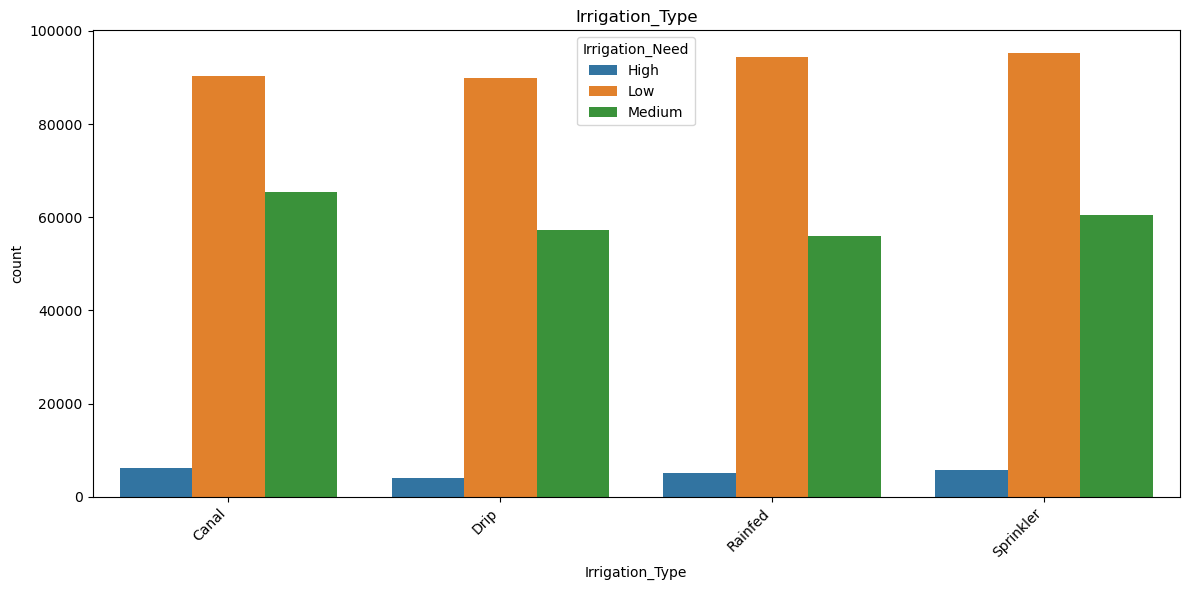

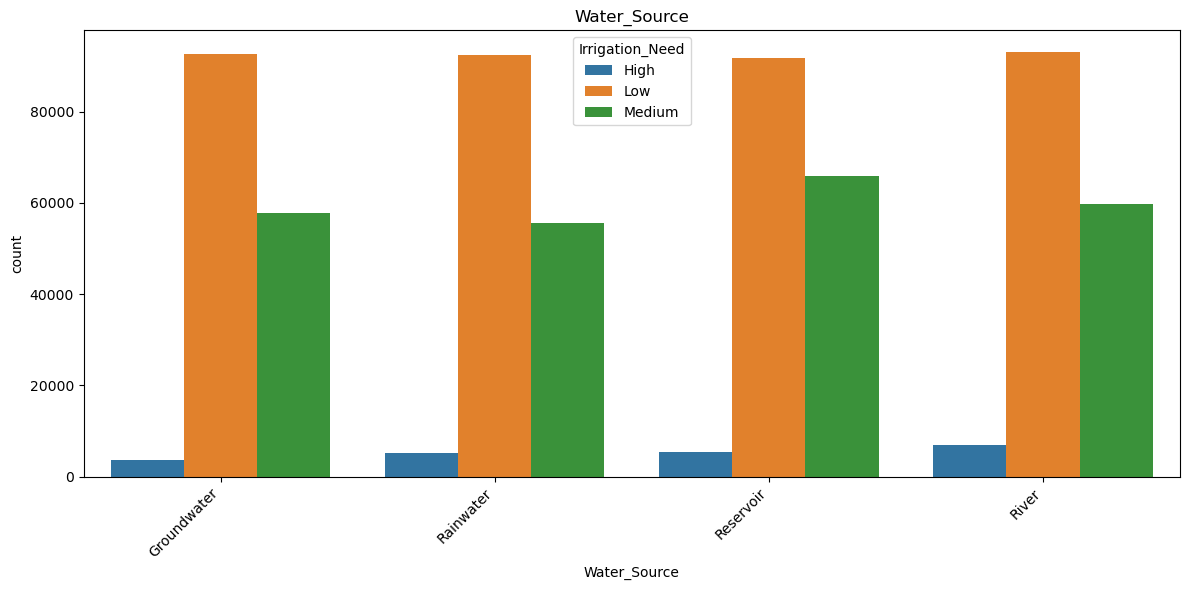

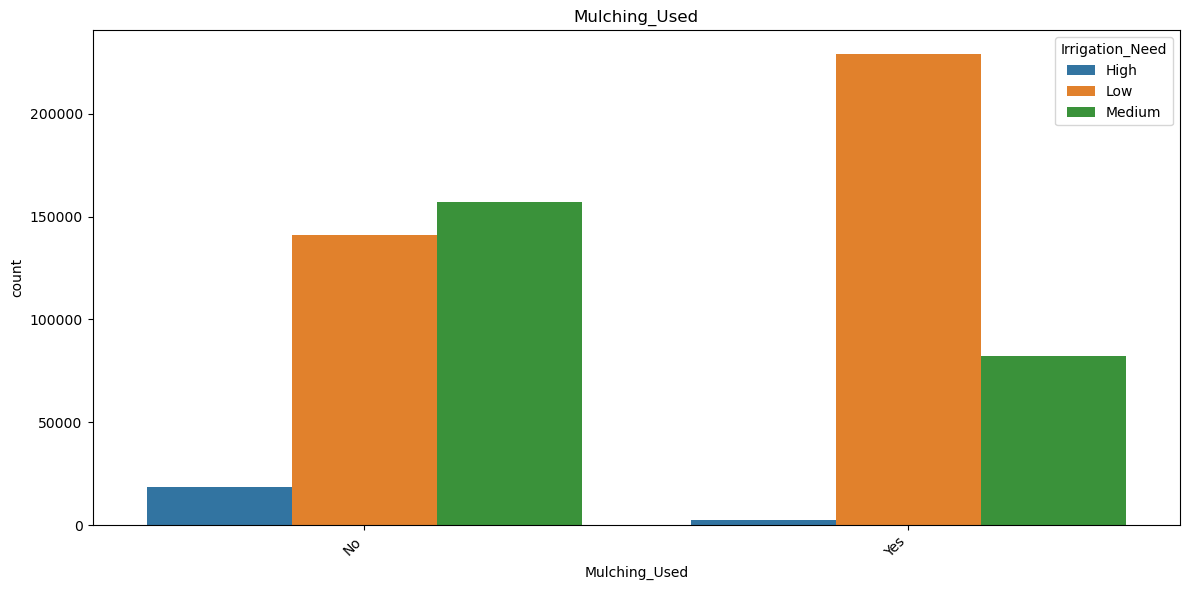

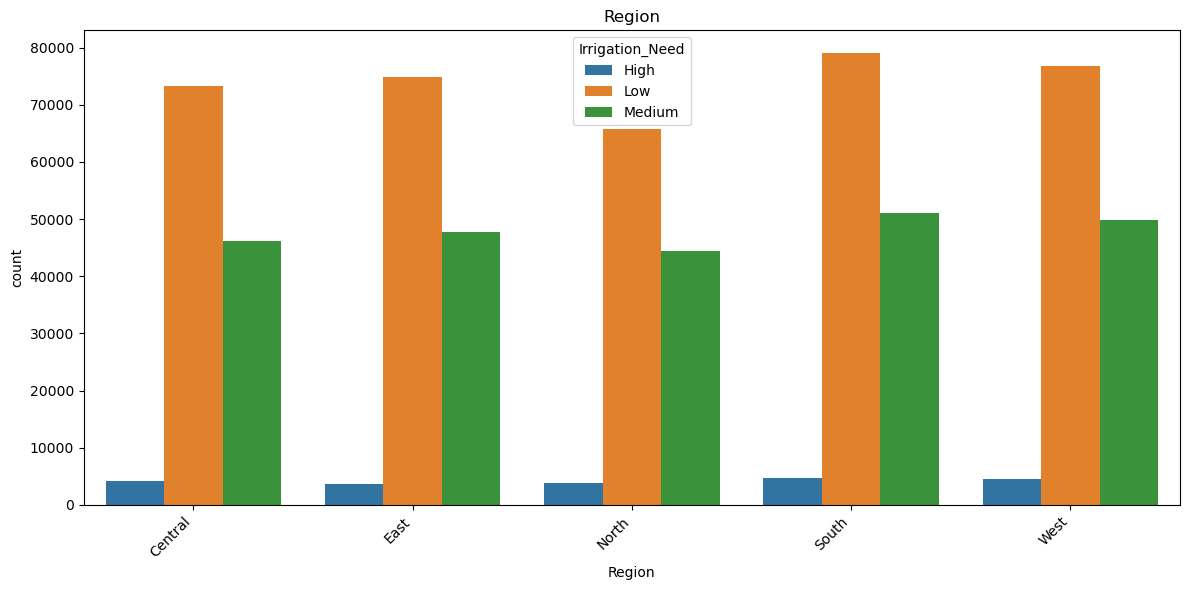

In [25]:
# Value counts for each categorical column, split by Churn
churn_col = 'Irrigation_Need' if 'Irrigation_Need' in train_df.columns else 'irrigation_need'
for f in train_df.select_dtypes(include=['object']).columns:
    if f == churn_col:
        continue
    plot_df = train_df.groupby([f, churn_col]).size().reset_index(name='count')
    sns.barplot(data=plot_df, x=f, y='count', hue=churn_col)
    plt.title(f)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Distributions (train vs test)

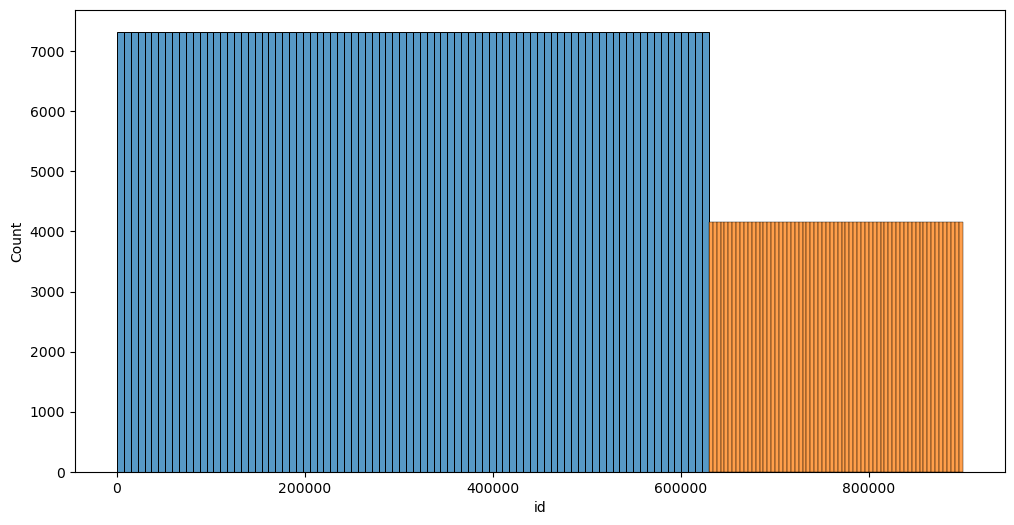

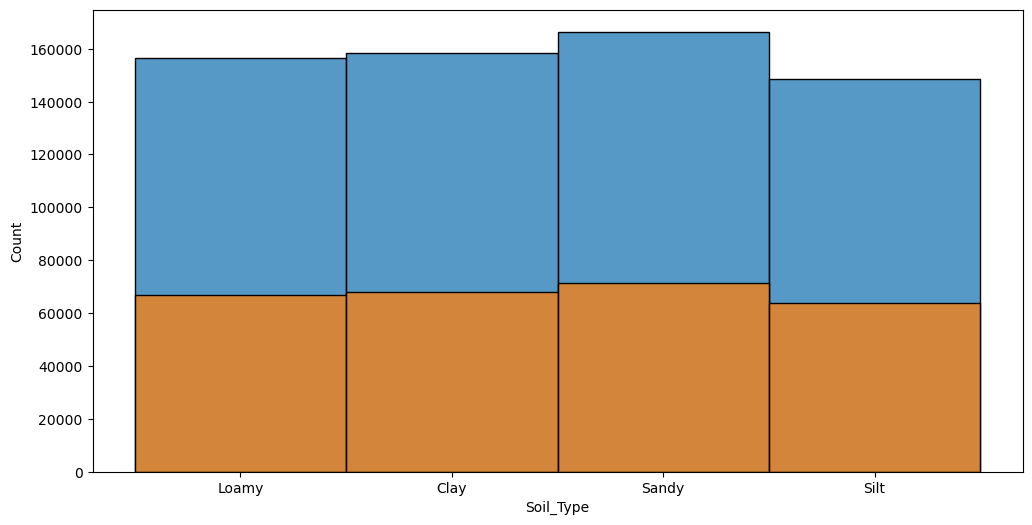

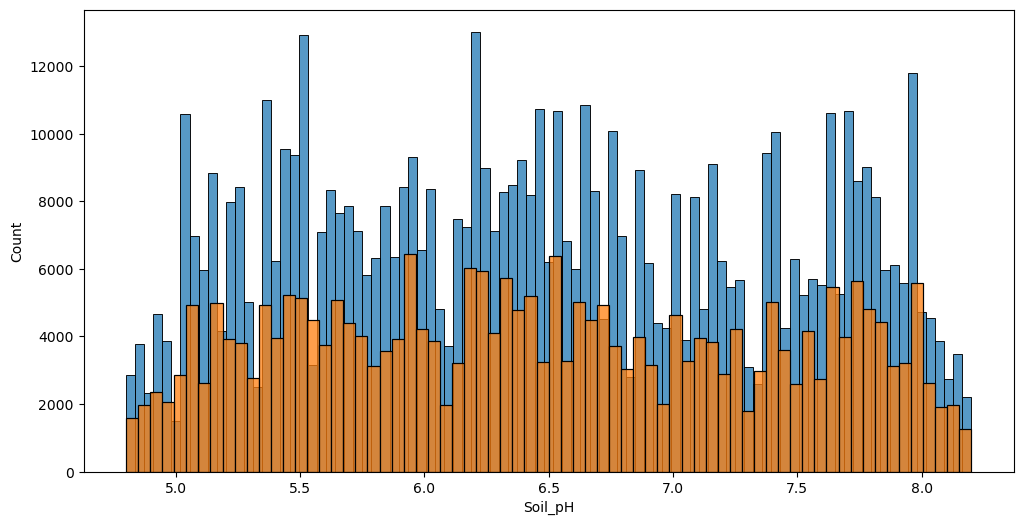

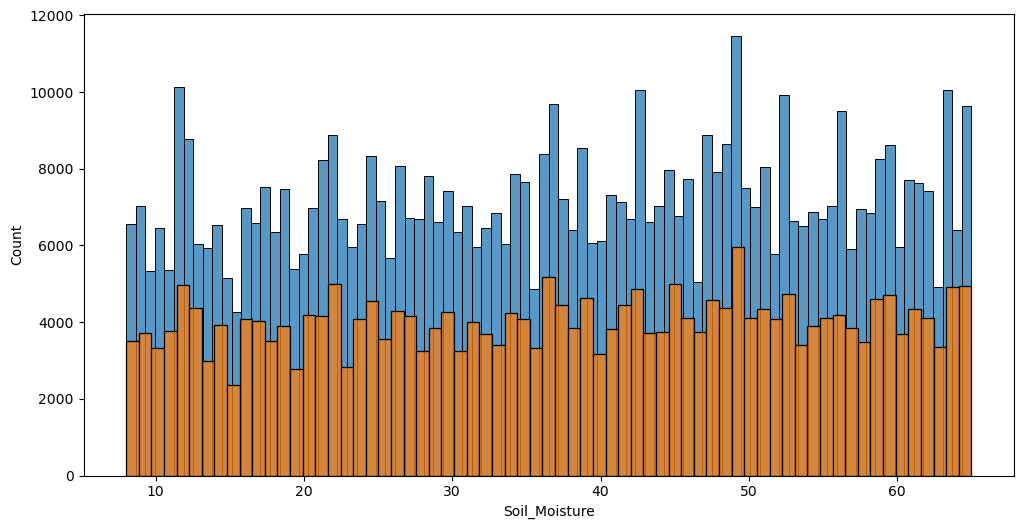

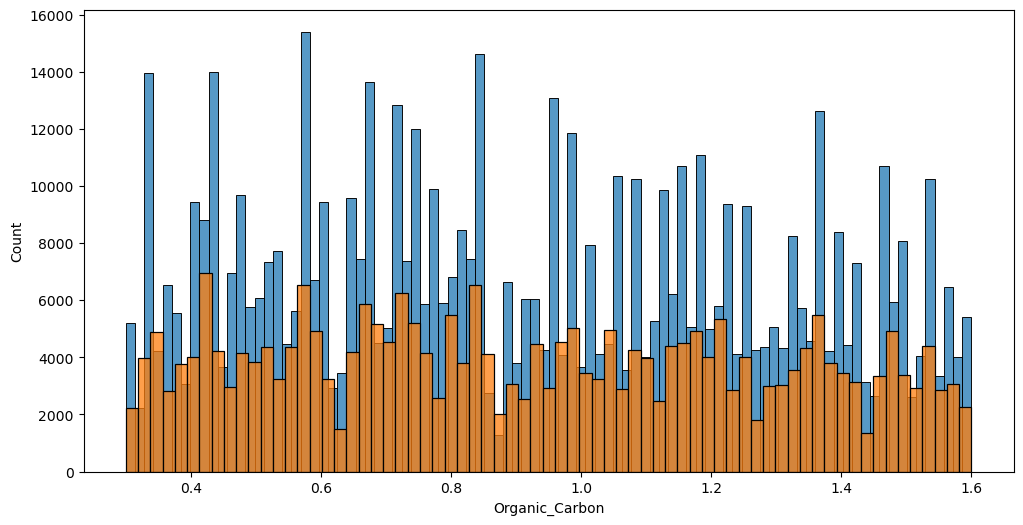

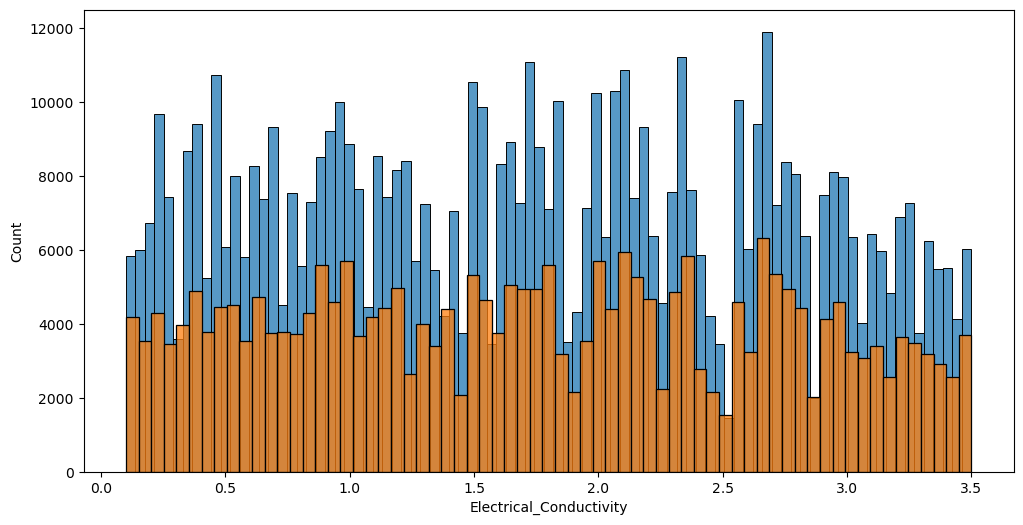

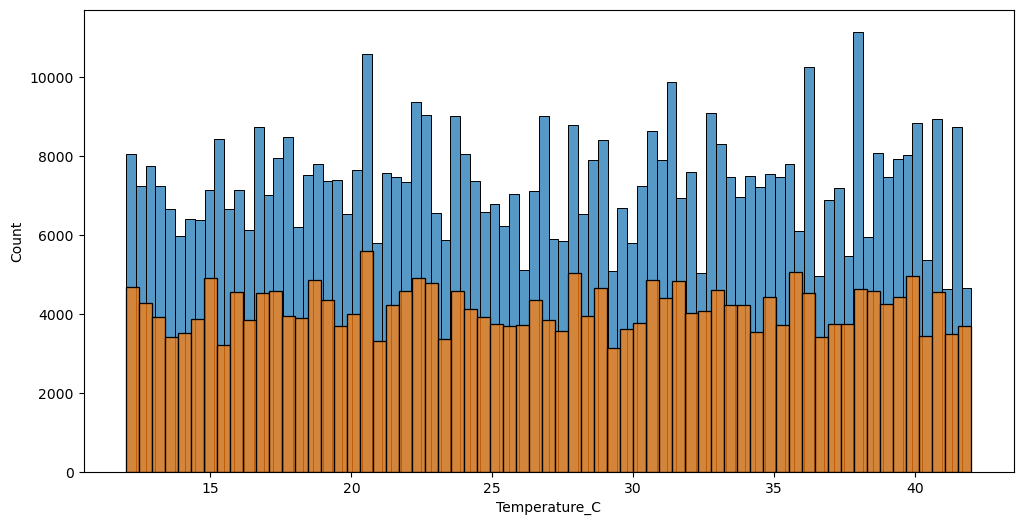

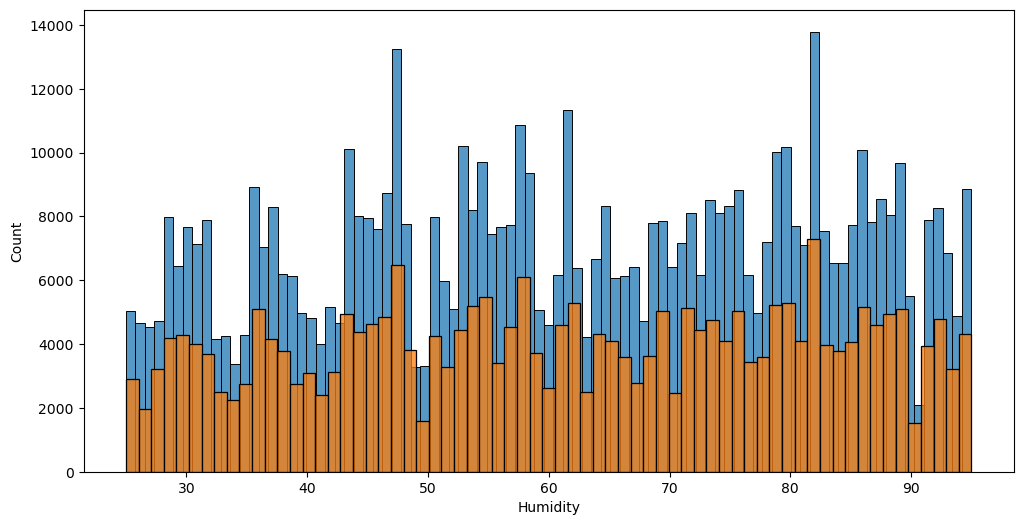

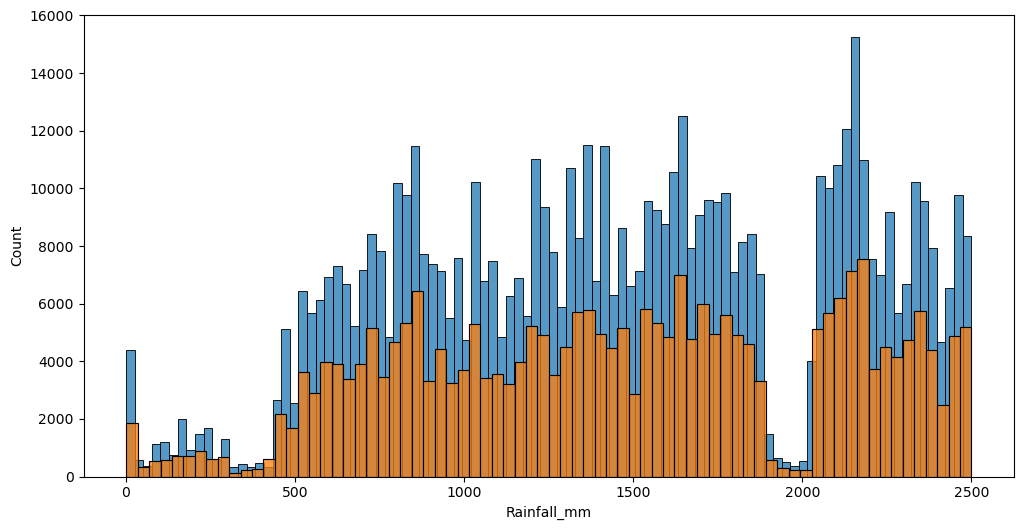

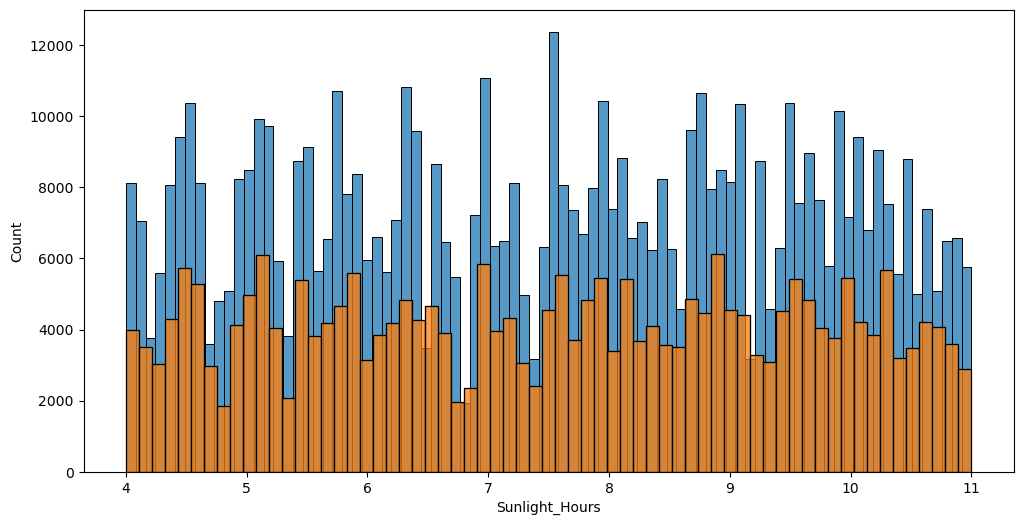

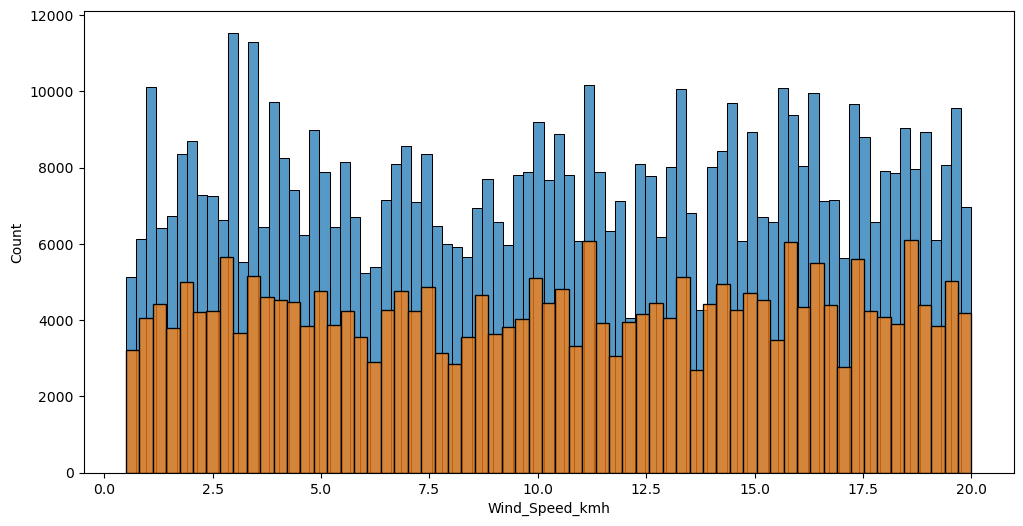

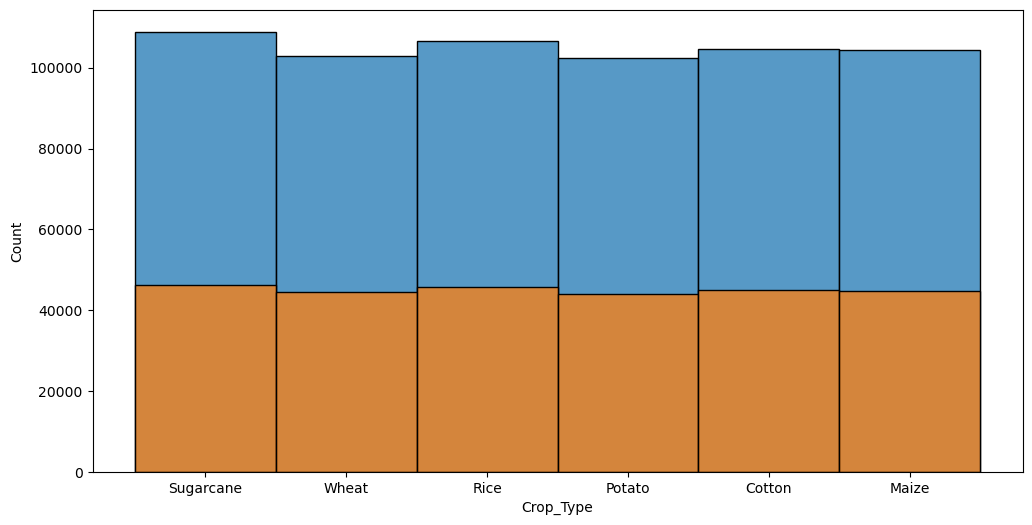

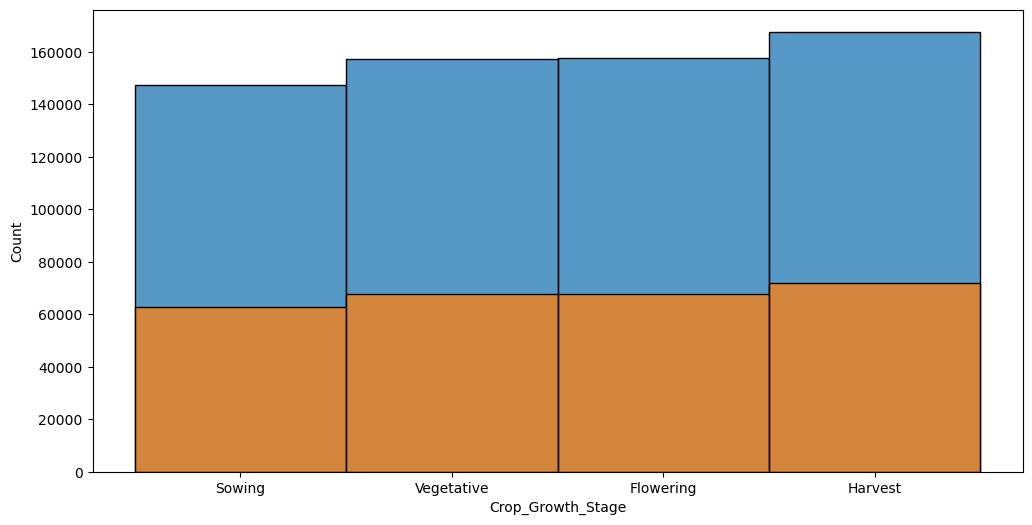

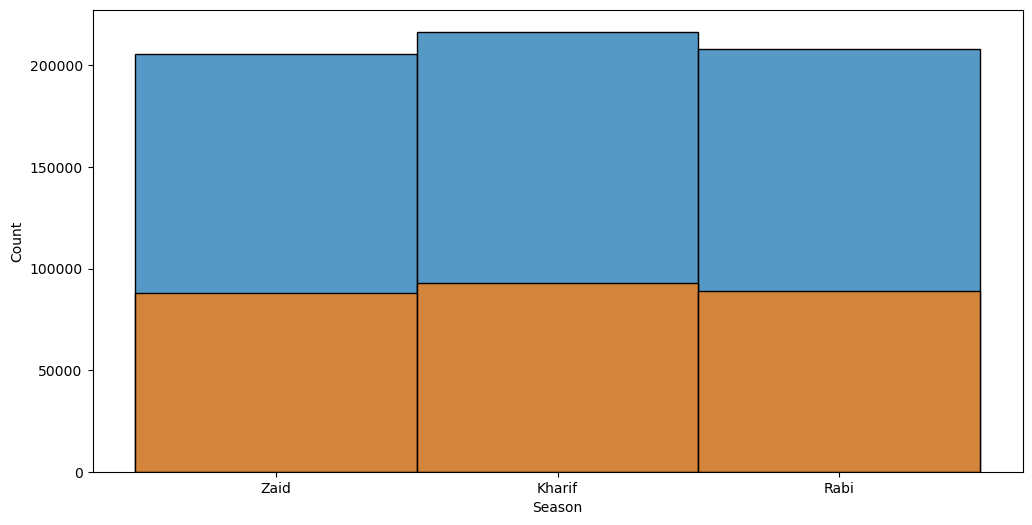

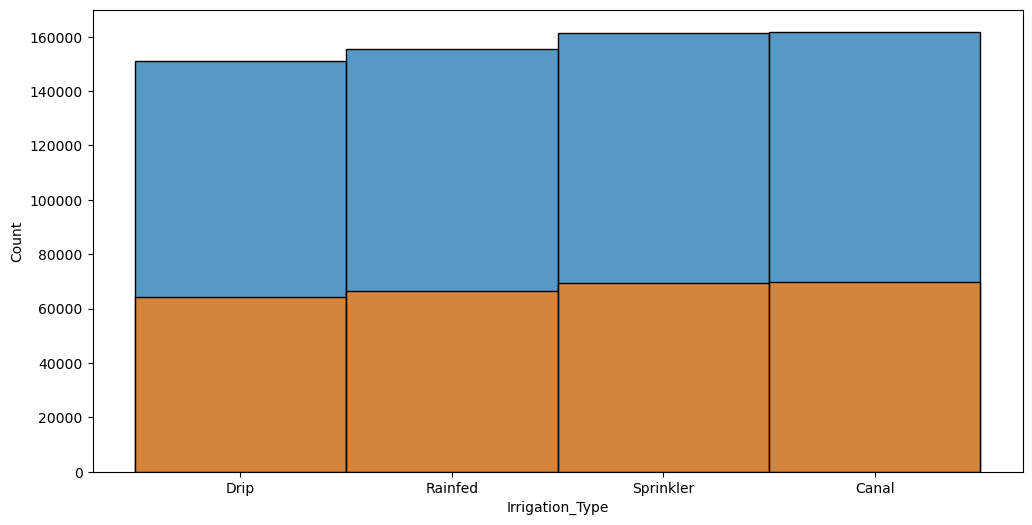

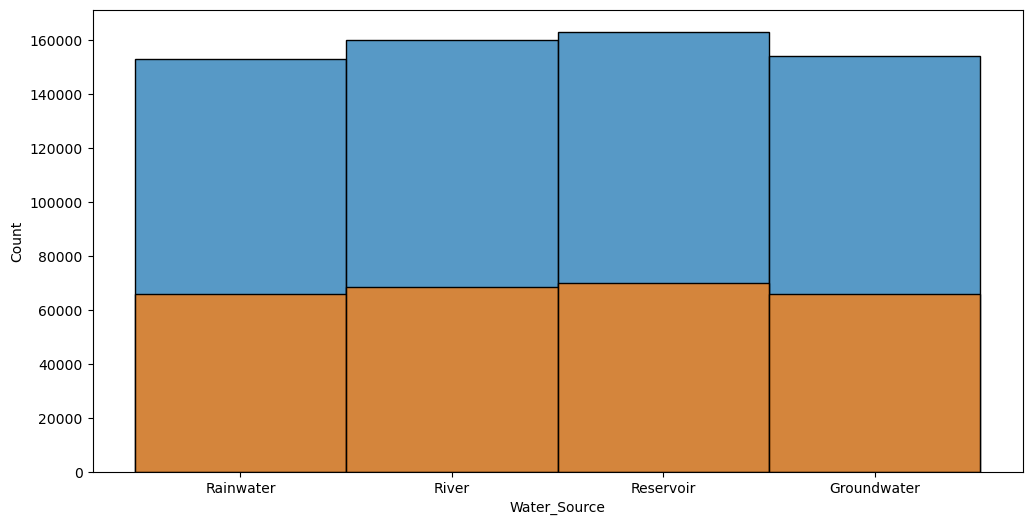

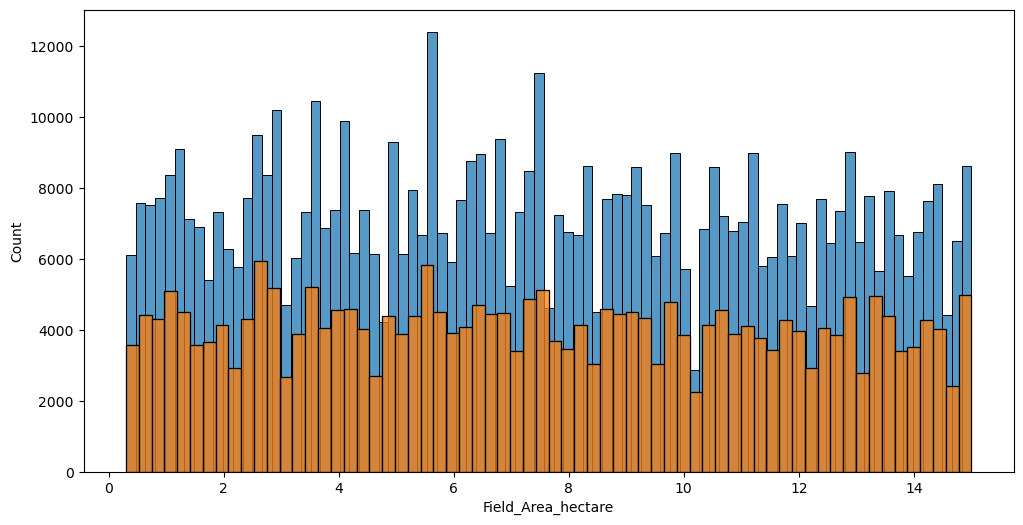

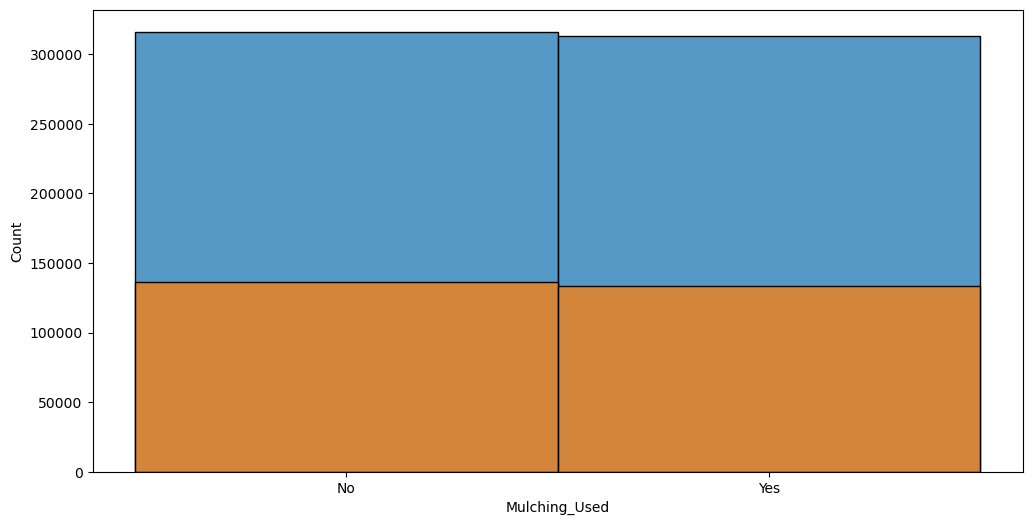

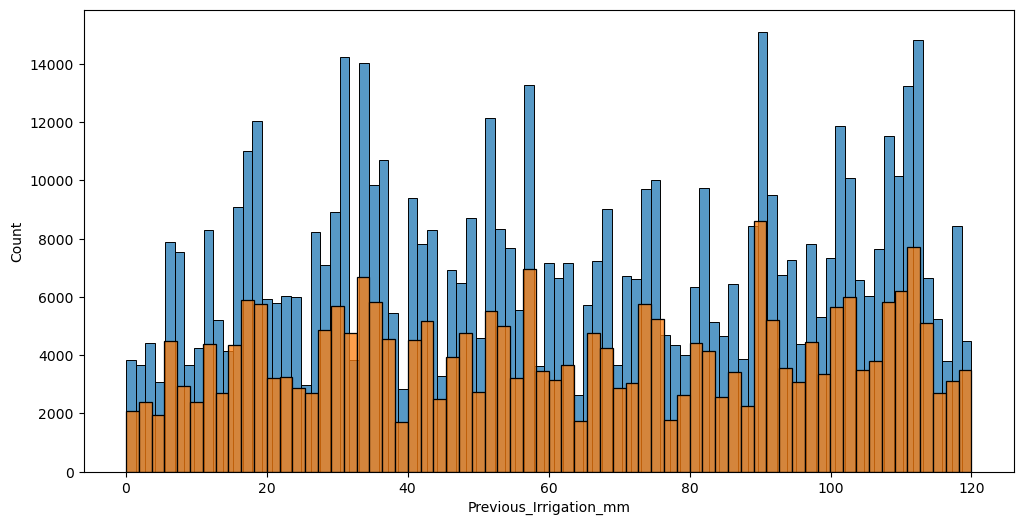

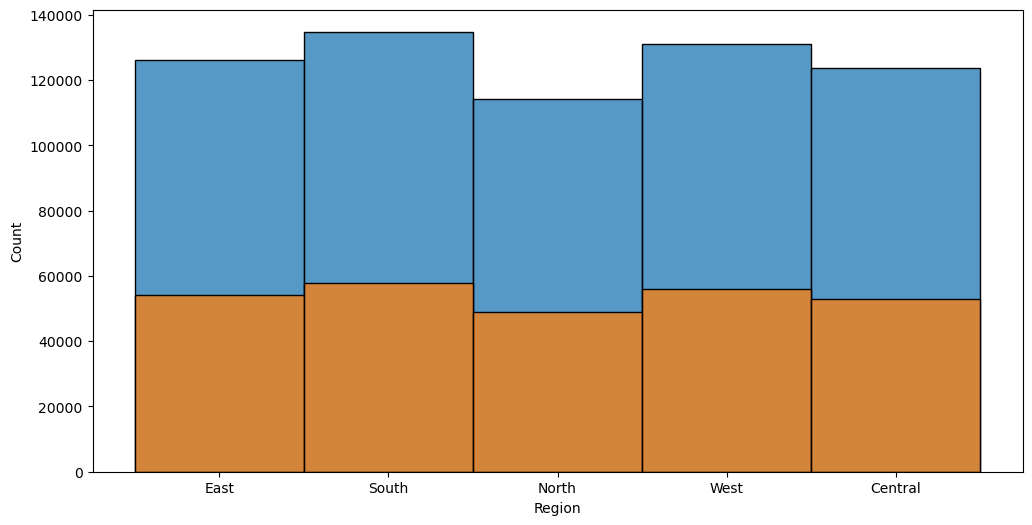

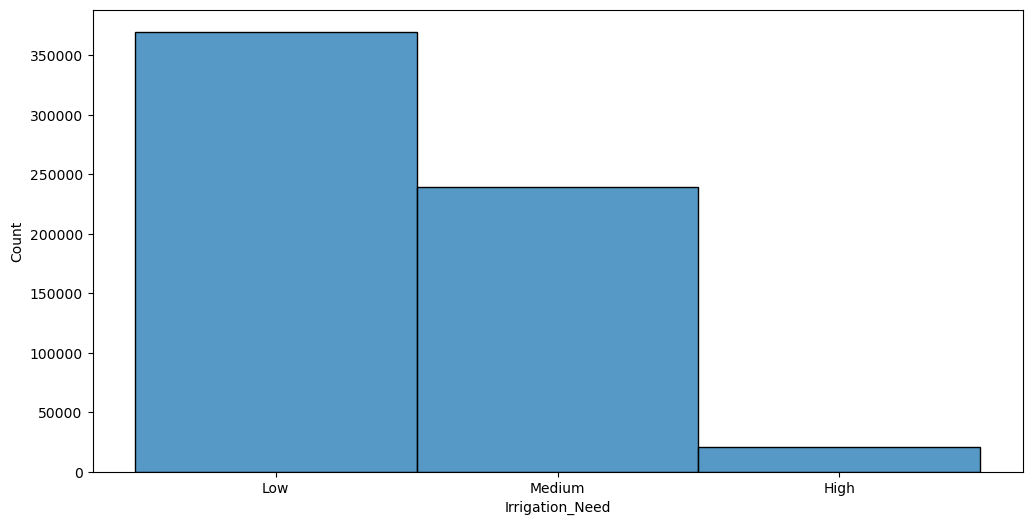

In [26]:
for col in train_df.columns:
    sns.histplot(train_df[col])
    if col in test_df.columns:
        sns.histplot(test_df[col])
    plt.show()

## Features

## Bar Charts

## Kmeans

## Scatter Plots

## Correlation Plots

In [27]:
df[target].value_counts()

irrigation_need
1    369917
2    239074
3     21009
Name: count, dtype: int64

In [28]:
df

,soil_ph,soil_moisture,organic_carbon,electrical_conductivity,temperature_c,humidity,rainfall_mm,sunlight_hours,wind_speed_kmh,field_area_hectare,previous_irrigation_mm,soil_type_Clay,soil_type_Loamy,soil_type_Sandy,soil_type_Silt,crop_type_Cotton,crop_type_Maize,crop_type_Potato,crop_type_Rice,crop_type_Sugarcane,crop_type_Wheat,crop_growth_stage_Flowering,crop_growth_stage_Harvest,crop_growth_stage_Sowing,crop_growth_stage_Vegetative,season_Kharif,season_Rabi,season_Zaid,irrigation_type_Canal,irrigation_type_Drip,irrigation_type_Rainfed,irrigation_type_Sprinkler,water_source_Groundwater,water_source_Rainwater,water_source_Reservoir,water_source_River,mulching_used_No,mulching_used_Yes,region_Central,region_East,region_North,region_South,region_West,irrigation_need
0,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,0.82,112.16,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,0,1
1,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,5.27,47.16,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1
2,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,8.24,110.38,1,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1
3,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,8.32,53.85,0,0,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,2
4,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,7.37,93.19,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,6.54,13.45,1.15,1.86,26.65,26.86,1041.33,10.62,18.85,4.35,118.36,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,2
629996,7.03,54.49,0.96,2.35,36.99,88.00,1419.57,9.93,17.99,12.97,40.75,1,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,2
629997,6.52,11.98,0.93,0.38,37.82,70.98,88.45,8.19,17.25,13.58,2.62,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,3
629998,5.93,42.86,0.33,3.39,34.99,94.58,2433.92,9.88,5.00,0.79,90.00,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,1,0,0,0,0,1,0,1,0,0,0,1


<Axes: >

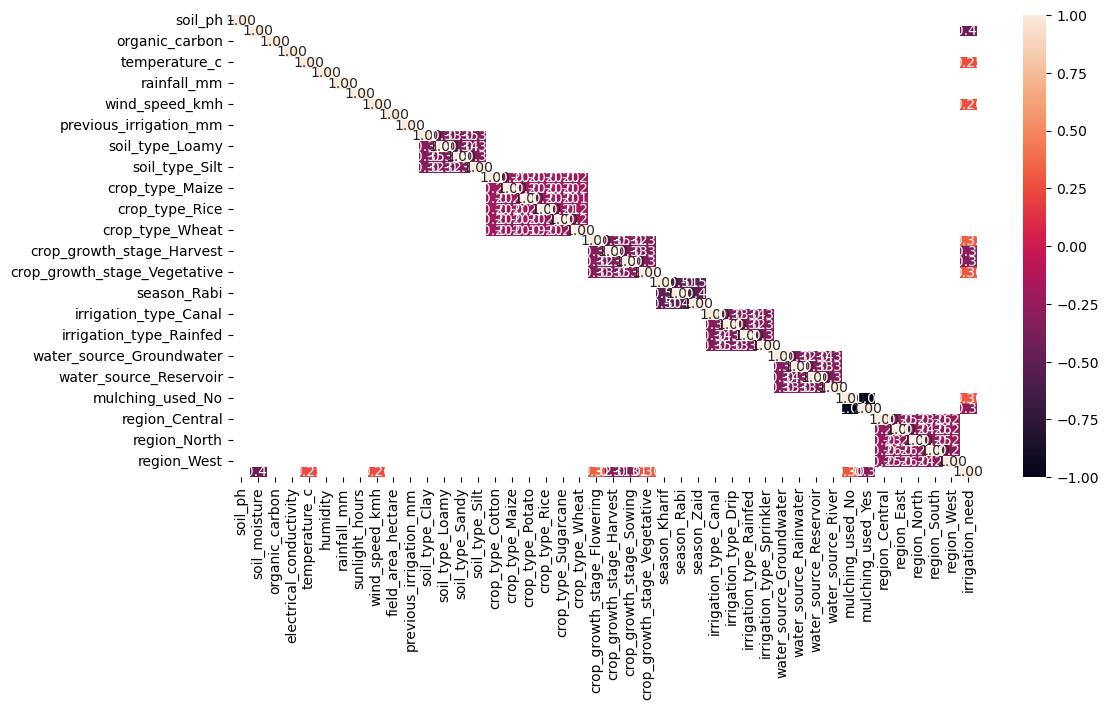

In [29]:
corr_matrix = df.corr(numeric_only=True)

mask = abs(corr_matrix) < 0.15

sns.heatmap(data=corr_matrix, mask=mask, fmt='.2f', annot=True)

<Axes: xlabel='irrigation_need'>

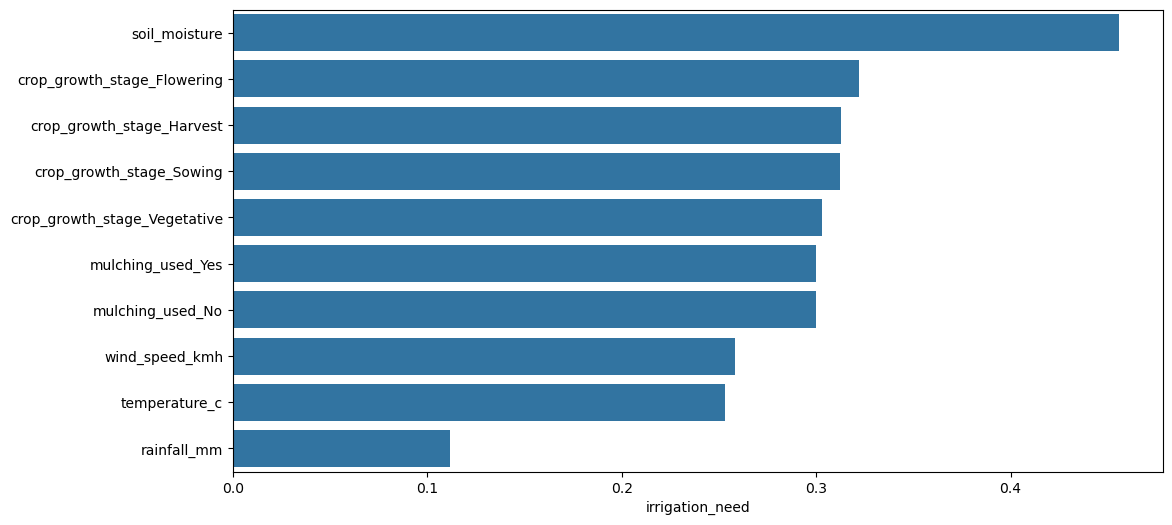

In [30]:
sns.barplot(corr_matrix[target].drop(target).abs().sort_values(ascending=False)[:10], orient='h')

In [31]:
corr_matrix[target].drop(target).abs().sort_values(ascending=False)[:10]

soil_moisture                   0.455482
crop_growth_stage_Flowering     0.321888
crop_growth_stage_Harvest       0.312770
crop_growth_stage_Sowing        0.312283
crop_growth_stage_Vegetative    0.302851
mulching_used_Yes               0.300043
mulching_used_No                0.300043
wind_speed_kmh                  0.258170
temperature_c                   0.252867
rainfall_mm                     0.111478
Name: irrigation_need, dtype: float64

## original data exploration

In [32]:
orig_df['Irrigation_Need'].value_counts()

Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

In [33]:
train_df.columns.to_list(), orig_df.columns.to_list()

(['id',
  'Soil_Type',
  'Soil_pH',
  'Soil_Moisture',
  'Organic_Carbon',
  'Electrical_Conductivity',
  'Temperature_C',
  'Humidity',
  'Rainfall_mm',
  'Sunlight_Hours',
  'Wind_Speed_kmh',
  'Crop_Type',
  'Crop_Growth_Stage',
  'Season',
  'Irrigation_Type',
  'Water_Source',
  'Field_Area_hectare',
  'Mulching_Used',
  'Previous_Irrigation_mm',
  'Region',
  'Irrigation_Need'],
 ['Soil_Type',
  'Soil_pH',
  'Soil_Moisture',
  'Organic_Carbon',
  'Electrical_Conductivity',
  'Temperature_C',
  'Humidity',
  'Rainfall_mm',
  'Sunlight_Hours',
  'Wind_Speed_kmh',
  'Crop_Type',
  'Crop_Growth_Stage',
  'Season',
  'Irrigation_Type',
  'Water_Source',
  'Field_Area_hectare',
  'Mulching_Used',
  'Previous_Irrigation_mm',
  'Region',
  'Irrigation_Need'])